In [79]:
# fast ai classification example

from fastai.vision.all import *
import pandas as pd
from pathlib import Path 
import torch
import matplotlib.pyplot as plt

# 1) Load CSV
df = pd.read_csv('labels.csv')  # expects columns: fname, label
df["fname"] = [Path(p).name for p in df["img_path"]]

In [49]:

# 2) Build DataLoaders (random train/valid split)
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock),                 # binary as 2 categories
    get_x=ColReader('fname', pref='cropped_images/'),   # path: cropped_imgs/<fname>
    get_y=ColReader('label'),                           # label from CSV
    splitter=RandomSplitter(valid_pct=0.2, seed=42),    # 80/20 split
    batch_tfms=aug_transforms()                         # light defaults
).dataloaders(df, bs=64)


In [78]:
# 3) Create a learner and train
learn = vision_learner(dls, resnet18, metrics=[accuracy, RocAucBinary()], cbs=CSVLogger(fname="history.csv", append=True))  # RocAucBinary needs fastai>=2.7
learn.fine_tune(20)

epoch,train_loss,valid_loss,accuracy,roc_auc_score,time
0,1.102059,0.851991,0.600766,0.654060,00:04


epoch,train_loss,valid_loss,accuracy,roc_auc_score,time
0,0.817051,0.635815,0.691188,0.752029,00:04
1,0.724114,0.554326,0.721073,0.808353,00:04
2,0.636492,0.513280,0.736398,0.828796,00:04
3,0.562830,0.492559,0.752490,0.841360,00:04
4,0.500714,0.459992,0.773946,0.862696,00:04
5,0.441510,0.419447,0.786973,0.885310,00:04
6,0.408817,0.400699,0.812261,0.901124,00:04
7,0.368353,0.362468,0.845211,0.919597,00:04
8,0.324731,0.392699,0.829885,0.910947,00:04
9,0.317017,0.347540,0.838314,0.925178,00:04


In [82]:
hist = hist.iloc[2:,]

In [95]:
# hist = hist.astype(float, errors='ignore')
for col in hist.columns:
    if hist[col].dtype == 'object':
        hist[col] = pd.to_numeric(hist[col], errors='coerce')

In [96]:
hist.train_loss.dtype

dtype('float64')

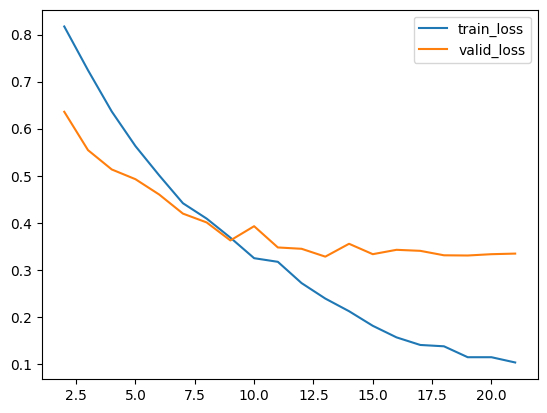

In [97]:
# Later: read + plot the whole history
# hist = pd.read_csv(learn.path/'history.csv')
hist[['train_loss', 'valid_loss']].plot()
plt.show()

Top losses:


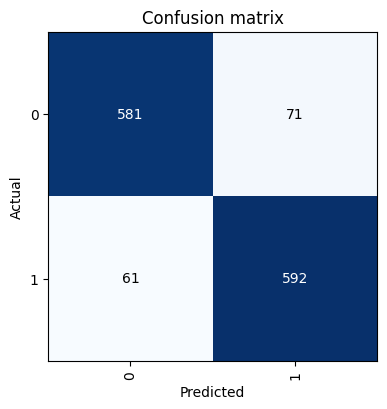

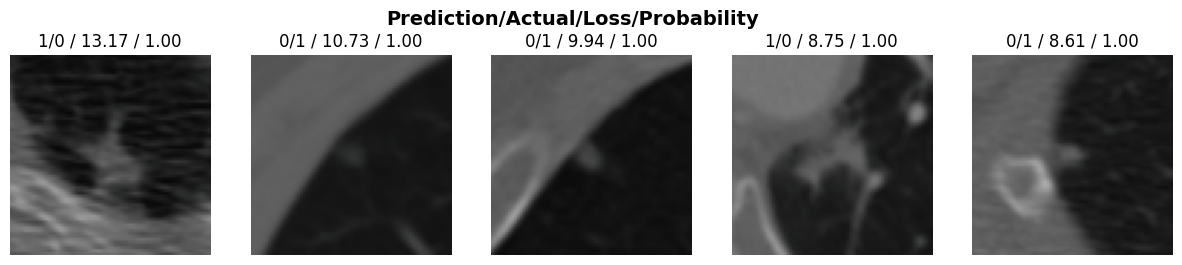

In [67]:

# 4) (Optional) Quick evaluation
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix(figsize=(4,4))
print("Top losses:")
interp.plot_top_losses(5, nrows=1)

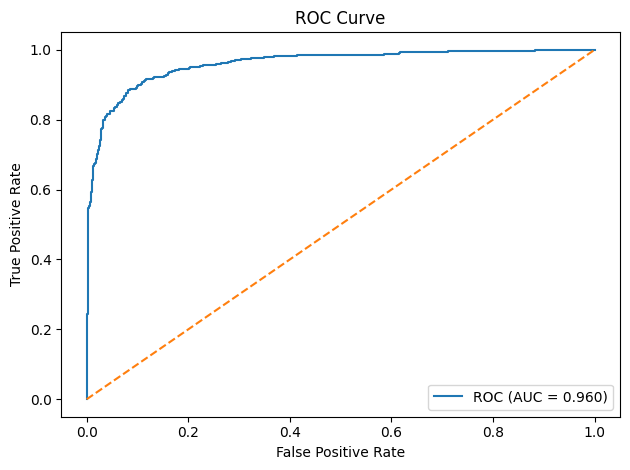

In [69]:
# (b) ROC curve (binary)
preds, targs = learn.get_preds()     # preds: probs for each class (N,2); targs: ints {0,1}
probs_pos = preds[:, 1]              # probability of the positive class
fpr, tpr, _ = roc_curve(targs.numpy(), probs_pos.numpy())
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=150)
plt.show()